# Sentiment Analysis of YouTube Comments  


## Step 1: Data Collection
- Extract comments by video_id  
- Store in DataFrame  

## Step 2: Preprocessing
- Handle missing values  
- Remove duplicates  
- Normalize text (optional)  

## Step 3: Emoji-based Sentiment Classification
- Define positive, negative, neutral emoji sets  
- Apply classification function to comments   



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
data=pd.read_csv('comments_clean.csv')

**Function quick overview**

In [ ]:
def quick_overview(data):

    for col in data.columns:
        if data[col].dtype == 'object':
            data[col] = pd.to_numeric(data[col].str.replace(',','', regex=False), errors='ignore')

    print("===== SHAPE =====")
    print(data.shape)

    print("\n===== INFO =====")
    print(data.info())

    print("\n===== MISSING VALUES =====")
    print(data.isnull().sum())

    print("\n===== UNIQUE VALUES =====")
    print(data.nunique())

    print("\n=====Categorical columns=====")
    categorical_cols = data.select_dtypes(include='object').columns
    print(categorical_cols)

    print("\n=====Numeric columns======")
    numeric_cols = data.select_dtypes(include='number').columns
    print(numeric_cols)

    if len(numeric_cols) > 0:
        print("\n===== BASIC STATISTICS =====")
        print(data[numeric_cols].describe().T)

        print("\n===== MEDIAN =====")
        print(data[numeric_cols].median())

        print("\n===== QUANTILES =====")
        print(data[numeric_cols].quantile([0.25, 0.5, 0.75]))

    print("\n===== DUPLICATES =====")
    print(data.duplicated().sum())

In [ ]:
quick_overview(data)

/tmp/ipython-input-885998229.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data[col] = pd.to_numeric(data[col].str.replace(',','', regex=False), errors='ignore')


===== SHAPE =====
(55963, 9)

===== INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55963 entries, 0 to 55962
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   comment_id    55963 non-null  object
 1   author        55963 non-null  object
 2   text          55955 non-null  object
 3   published_at  55963 non-null  object
 4   like_count    55963 non-null  int64 
 5   reply_count   55963 non-null  int64 
 6   video_id      55963 non-null  object
 7   sentiment     166 non-null    object
 8   clean_text    55768 non-null  object
dtypes: int64(2), object(7)
memory usage: 3.8+ MB
None

===== MISSING VALUES =====
comment_id          0
author              0
text                8
published_at        0
like_count          0
reply_count         0
video_id            0
sentiment       55797
clean_text        195
dtype: int64

===== UNIQUE VALUES =====
comment_id      55963
author          47619
text            46

In [ ]:
data.shape

(55963, 9)

In [ ]:
import re

# Regex pattern: hər hansı rəqəm (0-9) varsa, təkbaşına və ya cümlə içində
pattern_numbers = r'\d'

mask = (
    data['text'].str.contains(r'anyone', case=False, na=False) |  # hər yerdə "anyone"
    data['text'].str.contains(pattern_numbers, regex=True, na=False)  # hər hansı rəqəm varsa
)

print("Silinəcək comment sayı:", mask.sum())
print("Qalan comment sayı:", len(data) - mask.sum())


data = data[~mask].reset_index(drop=True)

Silinəcək comment sayı: 0
Qalan comment sayı: 55963


In [ ]:
data = data.dropna(subset=['author']).reset_index(drop=True)
 # deleting only  author - column s null

In [ ]:
data[["video_id"]].value_counts()

,count
video_id,
Zi_XLOBDo_Y,55963


In [ ]:
pip install transformers

Cleaning text column

In [ ]:
import re
import pandas as pd

def clean_text(text):
    if pd.isna(text):
        return ""

    # HTML tags
    text = re.sub(r'<.*?>', '', text)

    # URLs
    text = re.sub(r'http\S+|www.\S+', '', text)

    # mentions
    text = re.sub(r'@\w+', '', text)

    # hashtags
    text = re.sub(r'#\w+', '', text)

    # remove isolated numbers (e.g., "123", "2024"), but not percentages like 100%
    text = re.sub(r'\b\d+\b', '', text)

    # merge multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # keep emojis properly
    emoji_pattern = (
        r'[^\w\s'
        r'\U0001F300-\U0001F6FF'  # Misc emojis
        r'\U0001F900-\U0001F9FF'  # Supplemental emojis
        r'\U0001FA70-\U0001FAFF'  # Symbols & pictographs
        r'\U00002700-\U000027BF'  # Dingbats
        r'\U00002600-\U000026FF'  # Misc symbols (includes hearts like 🖤)
        r'\U0001F1E0-\U0001F1FF'  # Flags
        r']'
    )
    text = re.sub(emoji_pattern, '', text)

    # lowercase
    text = text.lower()

    return text

# Apply cleaning
data["clean_text"] = data["text"].apply(clean_text)

# Save
data.to_csv("comments_clean.csv", index=False, encoding="utf-8")

print("Cleaning completed. New file saved as comments_clean.csv")
print(data[["text", "clean_text"]].head())


# Show example
print(data[['text', 'clean_text']].head())


Cleaning completed. New file saved as comments_clean.csv
                                                text  \
0                                                 Me   
1                         Mzlsosldido❤❤❤❤❤❤❤❤❤❤❤😊😊😊😊   
2                                           Temazo 😢   
3                                           Im about   
4  Ainda espero pelo dia q ele vai aparecer vivo ...   

                                          clean_text  
0                                                 me  
1                         mzlsosldido❤❤❤❤❤❤❤❤❤❤❤😊😊😊😊  
2                                           temazo 😢  
3                                           im about  
4  ainda espero pelo dia q ele vai aparecer vivo ...  
                                                text  \
0                                                 Me   
1                         Mzlsosldido❤❤❤❤❤❤❤❤❤❤❤😊😊😊😊   
2                                           Temazo 😢   
3                                           Im about

In [ ]:
data_clean=pd.read_csv('comments_clean.csv')

In [ ]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55963 entries, 0 to 55962
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   comment_id    55963 non-null  object
 1   author        55963 non-null  object
 2   text          55955 non-null  object
 3   published_at  55963 non-null  object
 4   like_count    55963 non-null  int64 
 5   reply_count   55963 non-null  int64 
 6   video_id      55963 non-null  object
 7   sentiment     166 non-null    object
 8   clean_text    55768 non-null  object
dtypes: int64(2), object(7)
memory usage: 3.8+ MB


In [ ]:
data_clean.isnull().sum()

,0
comment_id,0
author,0
text,8
published_at,0
like_count,0
reply_count,0
video_id,0
sentiment,55797
clean_text,195


In [ ]:
data_clean["clean_text"].isnull().sum()

np.int64(195)

In [ ]:
# deleting only clean_text columns null values
data_clean = data_clean.dropna(subset=['clean_text']).reset_index(drop=True)

print("Datasetdəki sətir sayı (clean_text null-lardan sonra):", len(data_clean))
print("clean_text sütununda null sayı:", data_clean["clean_text"].isnull().sum())


Datasetdəki sətir sayı (clean_text null-lardan sonra): 55768
clean_text sütununda null sayı: 0


In [ ]:
data_clean

,comment_id,author,text,published_at,like_count,reply_count,video_id,sentiment,clean_text
0,Ugyaeyi_Ogj9x-XjB554AaABAg,@edwinrios867,Me,2025-08-16T16:15:10Z,1,0,Zi_XLOBDo_Y,neutral,me
1,Ugx9Vgq1EHevn5UjbiF4AaABAg,@MarthaTriguy,Mzlsosldido❤❤❤❤❤❤❤❤❤❤❤😊😊😊😊,2025-08-16T16:05:15Z,0,0,Zi_XLOBDo_Y,positive,mzlsosldido❤❤❤❤❤❤❤❤❤❤❤😊😊😊😊
2,Ugw-s85yDs7jYU9vmx94AaABAg,@JuegosJUEGOS-sx6uu,Temazo 😢,2025-08-16T16:02:10Z,0,0,Zi_XLOBDo_Y,NaN,temazo 😢
3,UgyNuSXZF3CILna6wFJ4AaABAg,@InkumbuBweupe-er4rn,Im about,2025-08-16T15:59:48Z,1,0,Zi_XLOBDo_Y,NaN,im about
4,UgzznieeyIqYcqLogHF4AaABAg,@FabianeCristina-wb6nx,Ainda espero pelo dia q ele vai aparecer vivo ...,2025-08-16T15:33:26Z,0,0,Zi_XLOBDo_Y,NaN,ainda espero pelo dia q ele vai aparecer vivo ...
...,...,...,...,...,...,...,...,...,...
55763,Ugyah00l32QzedJjSqF4AaABAg,@lucaspetricor,Deixo aqui meu comentário nessa maravilha da h...,2022-06-24T00:58:46Z,1,0,Zi_XLOBDo_Y,NaN,deixo aqui meu comentário nessa maravilha da h...
55764,Ugxlg59kY1t3QMziTY14AaABAg,@jaysosa223,😢man we lost a legend,2022-06-24T00:33:54Z,2,0,Zi_XLOBDo_Y,NaN,😢man we lost a legend
55765,UgxFboIheaSShfjdBbx4AaABAg,@Josi560,አይገርምም ማይክል ጃክሰንን ጊዜ ባገኘሁ ቁጥር ምሰማው ምርጥ ንጉስ ነብስ...,2022-06-23T23:14:19Z,7,0,Zi_XLOBDo_Y,NaN,አይገርምም ማይክል ጃክሰንን ጊዜ ባገኘሁ ቁጥር ምሰማው ምርጥ ንጉስ ነብስ...
55766,UgzQ4zW4WdXONc9avt14AaABAg,@thewonfamily8788,Yessssss michael jackson get it bille Jean yes...,2022-06-23T23:01:14Z,3,0,Zi_XLOBDo_Y,NaN,yessssss michael jackson get it bille jean yes...


Step 3: Emoji-based Sentiment Classification

In [ ]:
import os
from transformers import pipeline

positive_emoji = [
    "😀","😃","😄","😁","😆","😊","😅","😸","😺","😻",
    "😍","🥰","😘","😚","😙","💋","❤️","💖","💗","💓","💕","💞","💝","🖤",
    "👍","💪","🏆","🥇","🎖","👑","🦁","🦅","🚀","💎","🔥","💯",
    "🎉","🎊","🥳","👏","🙌","🤗","🤝","🌟","🌈","🍀","✨",
    "😎","😇","🌞","🌺","🌸","🌻","🍓","🍎","🍫","🍭",
    "🎶","🎵","🎂","🍰","🥂","🍷","🍻","🏖","🌍","✈️",
    "🤩","😌","🤟","✌️","🙆","🧘","🕊","🌅","🌄","🌠","🎇","🎆"
]

negative_emoji = [
    "😢","😭","😿","🥺","😞","😔","☹️","🙁","😣","😖",
    "😡","😠","🤬","😤","💢","👿","🖕","👎","❌","📉",
    "😱","😨","😰","😧","😦","😟","🤯","😫","😩","🥵","🥶",
    "⛈","🌪","🌋","🩸","🔪","🕳","⚰️","⚡",
    "😵","😵‍💫","🤢","🤮","😷","🤒","🤕","☠️","💀","🪦"
]

neutral_emoji = [
    "😐","😶","😑","😏","😒","😶‍🌫️",
    "🤔","🤨","🧐","🙄","🤷","🤫","🤭","💭","🔍",
    "🤓","📚","📖","🗂","📅","🖊","📎","🛑","🌀",
    "😮","😯","😲","😳","😬","😴","😪","🛌","⌛","⏳","📌","📍"
]

# HuggingFace sentiment pipeline (cutting long tex)
sentiment_model = pipeline(
    "sentiment-analysis",
    model="AmaanP314/youtube-xlm-roberta-base-sentiment-multilingual",
    tokenizer="AmaanP314/youtube-xlm-roberta-base-sentiment-multilingual",
    device=-1,
    truncation=True,
    max_length=512
)

batch_size = 32
sentiments = []

texts = data_clean["clean_text"].astype(str).tolist()
for i in range(0, len(texts), batch_size):
    batch = texts[i:i+batch_size]
    batch_sentiments = []

    for t in batch:
        if any(e in t for e in positive_emoji):
            batch_sentiments.append("positive")
        elif any(e in t for e in negative_emoji):
            batch_sentiments.append("negative")
        elif any(e in t for e in neutral_emoji):
            batch_sentiments.append("neutral")
        else:
            batch_sentiments.append(None)

    # Use model for the remaining ones
    to_model = [t for idx, t in enumerate(batch) if batch_sentiments[idx] is None]
    if to_model:
        results = sentiment_model(to_model, truncation=True, max_length=512)
        j = 0
        for idx, val in enumerate(batch_sentiments):
            if val is None:
                label = results[j]['label']
                if label.upper().startswith("POS"):
                    batch_sentiments[idx] = "positive"
                elif label.upper().startswith("NEG"):
                    batch_sentiments[idx] = "negative"
                else:
                    batch_sentiments[idx] = "neutral"
                j += 1

    sentiments.extend(batch_sentiments)

data_clean["sentiment"] = sentiments

data_clean.to_csv("comments_with_sentiment.csv", index=False, encoding="utf-8")

print(data["sentiment"].value_counts())

Device set to use cpu


NameError: name 'data_clean' is not defined

In [ ]:
new_data=pd.read_csv('comments_with_sentiment.csv')

In [ ]:
new_data[["sentiment"]].value_counts()

,count
sentiment,
positive,29101
neutral,20063
negative,6604


In [ ]:
data

,comment_id,author,text,published_at,like_count,reply_count,video_id,sentiment,clean_text
0,Ugyaeyi_Ogj9x-XjB554AaABAg,@edwinrios867,Me,2025-08-16T16:15:10Z,1,0,Zi_XLOBDo_Y,neutral,me
1,Ugx9Vgq1EHevn5UjbiF4AaABAg,@MarthaTriguy,Mzlsosldido❤❤❤❤❤❤❤❤❤❤❤😊😊😊😊,2025-08-16T16:05:15Z,0,0,Zi_XLOBDo_Y,positive,mzlsosldido❤❤❤❤❤❤❤❤❤❤❤😊😊😊😊
2,Ugw-s85yDs7jYU9vmx94AaABAg,@JuegosJUEGOS-sx6uu,Temazo 😢,2025-08-16T16:02:10Z,0,0,Zi_XLOBDo_Y,NaN,temazo 😢
3,UgyNuSXZF3CILna6wFJ4AaABAg,@InkumbuBweupe-er4rn,Im about,2025-08-16T15:59:48Z,1,0,Zi_XLOBDo_Y,NaN,im about
4,UgzznieeyIqYcqLogHF4AaABAg,@FabianeCristina-wb6nx,Ainda espero pelo dia q ele vai aparecer vivo ...,2025-08-16T15:33:26Z,0,0,Zi_XLOBDo_Y,NaN,ainda espero pelo dia q ele vai aparecer vivo ...
...,...,...,...,...,...,...,...,...,...
55958,Ugyah00l32QzedJjSqF4AaABAg,@lucaspetricor,Deixo aqui meu comentário nessa maravilha da h...,2022-06-24T00:58:46Z,1,0,Zi_XLOBDo_Y,NaN,deixo aqui meu comentário nessa maravilha da h...
55959,Ugxlg59kY1t3QMziTY14AaABAg,@jaysosa223,😢man we lost a legend,2022-06-24T00:33:54Z,2,0,Zi_XLOBDo_Y,NaN,😢man we lost a legend
55960,UgxFboIheaSShfjdBbx4AaABAg,@Josi560,አይገርምም ማይክል ጃክሰንን ጊዜ ባገኘሁ ቁጥር ምሰማው ምርጥ ንጉስ ነብስ...,2022-06-23T23:14:19Z,7,0,Zi_XLOBDo_Y,NaN,አይገርምም ማይክል ጃክሰንን ጊዜ ባገኘሁ ቁጥር ምሰማው ምርጥ ንጉስ ነብስ...
55961,UgzQ4zW4WdXONc9avt14AaABAg,@thewonfamily8788,Yessssss michael jackson get it bille Jean yes...,2022-06-23T23:01:14Z,3,0,Zi_XLOBDo_Y,NaN,yessssss michael jackson get it bille jean yes...


In [ ]:
neutral_examples = new_data[new_data["sentiment"]=="neutral"]["text"].sample(20, random_state=42)
print(neutral_examples.tolist())

['It’s like this song is immortal no matter how old it is it will NEVER die', 'Me', 'Up', 'Trece', 'Por aqui❤', 'Someone here?', 'Били джин н скушай ау', 'He made this song when he let a little boy sleep in his bed', 'Yo gta vice city', 'You are so unique 🙄🤨', 'Good song', '♫', 'Muzan Jackson', 'Ba e cineva roman', 'no murio ?', '🤴', 'Baru tau cerita lagu ini tentang mj hamilin ank org 😂', 'hee heeee', 'He he', 'There will be only one Einstein Tesla Dostojevski Shakespear Michael Jackson not two but only one. And history writes novels.']


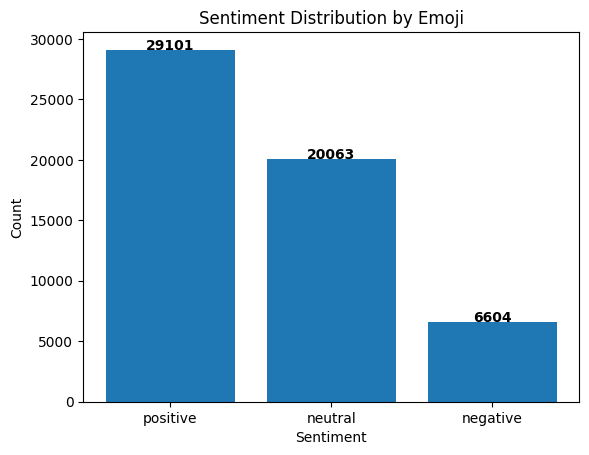

In [ ]:
import matplotlib.pyplot as plt

sent_counts = new_data["sentiment"].value_counts()

plt.bar(sent_counts.index, sent_counts.values)
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution by Emoji")


for i, v in enumerate(sent_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.show()

In [ ]:
pip install pandas emoji langdetect transformers torch


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 16.3 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=2ec2b2620a66137fef3b550a37f49eab6b58b12e799d210cac3eec0a9655e19f
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 10.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=b8ff7ce0cb2479697db50e71a29ac892a8d6b641f7338511dfd2f984c3641ced
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
!pip install googletrans==4.0.0-rc1

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 3.8 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-4.0.0rc1-py3-none-any.whl size=17396 sha256=d6912ce9cfa9692e433c84d2d9a3721f46eeb60955de12c798ffe4806a1b0a7c
  Stored in directory: /root/.cache/pip/wheels/95/0f/04/b17a72024b56a60e499ce1a6313d283ed5ba332407155bee03
Successfully built googletrans
  Attempting uninstall: hyperframe
    Found existing installation: hyperframe 6.1.0
    Uninstalling hyperfram

In [ ]:
from googletrans import Translator
from tqdm import tqdm
import time


tqdm.pandas()

translator = Translator()

def translate_text(text):
    try:
        if pd.isna(text) or text.strip() == "":
            return None
        translated = translator.translate(text, src="auto", dest="en")
        time.sleep(0.5)
        return translated.text
    except Exception as e:
        print("Xəta baş verdi:", e)
        return "TRANSLATION_ERROR"


print("lets translate  ...")
new_data["comments_eng"] = new_data["clean_text"].progress_apply(translate_text)

new_data.to_csv("comments_translated.csv", index=False)
print("Translate completed və 'comments_translated.csv' ")


lets translate  ...


  3%|▎         | 1399/55768 [16:37<10:54:58,  1.38it/s]

Xəta baş verdi: sequence item 1: expected str instance, NoneType found


  4%|▎         | 2064/55768 [24:19<10:44:47,  1.39it/s]

Xəta baş verdi: the JSON object must be str, bytes or bytearray, not NoneType


...

Xəta baş verdi: sequence item 2: expected str instance, NoneType found


 97%|█████████▋| 54240/55768 [10:52:37<20:55,  1.22it/s]

Xəta baş verdi: 'NoneType' object is not iterable


100%|██████████| 55768/55768 [11:11:04<00:00,  1.39it/s]


Translate completed və 'comments_translated.csv' 


In [7]:
data_translated=pd.read_csv('comments_translated.csv', encoding='utf-8')

In [ ]:
pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 38.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=9b9707f1a7ae90f6be55393d91fc45a828edda34eed9873e2b3f0d5cbee772e8
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [8]:
data_translated.head()

,comment_id,author,text,published_at,like_count,reply_count,video_id,sentiment,clean_text,comments_eng
0,Ugyaeyi_Ogj9x-XjB554AaABAg,@edwinrios867,Me,2025-08-16T16:15:10Z,1,0,Zi_XLOBDo_Y,neutral,me,me
1,Ugx9Vgq1EHevn5UjbiF4AaABAg,@MarthaTriguy,Mzlsosldido❤❤❤❤❤❤❤❤❤❤❤😊😊😊😊,2025-08-16T16:05:15Z,0,0,Zi_XLOBDo_Y,positive,mzlsosldido❤❤❤❤❤❤❤❤❤❤❤😊😊😊😊,mzlsosldido❤❤❤❤❤❤❤❤❤❤❤😊😊😊😊
2,Ugw-s85yDs7jYU9vmx94AaABAg,@JuegosJUEGOS-sx6uu,Temazo 😢,2025-08-16T16:02:10Z,0,0,Zi_XLOBDo_Y,negative,temazo 😢,great song 😢
3,UgyNuSXZF3CILna6wFJ4AaABAg,@InkumbuBweupe-er4rn,Im about,2025-08-16T15:59:48Z,1,0,Zi_XLOBDo_Y,neutral,im about,im about
4,UgzznieeyIqYcqLogHF4AaABAg,@FabianeCristina-wb6nx,Ainda espero pelo dia q ele vai aparecer vivo ...,2025-08-16T15:33:26Z,0,0,Zi_XLOBDo_Y,negative,ainda espero pelo dia q ele vai aparecer vivo ...,I still wait for the day he appears alive in B...


In [9]:
data_translated[["sentiment"]].value_counts()

,count
sentiment,
positive,29101
neutral,20063
negative,6604


In [11]:
positive_emoji = [

    "😀","😃","😄","😁","😆","😅","😂","🤣","😊","😇","🙂","☺️","😌","😋","😸","😺","😻","😽","😹","😼",
    "😍","🥰","😘","😚","😙","🤗","🤩","🥳","😎","🤠","😏","😌",

    "❤️","🩷","🧡","💛","💚","💙","💜","🤎","🖤","🤍",
    "💖","💗","💓","💕","💞","💝","💘","💟","💋","💫","💐","🌸","🌹","🌻","🌷","🌼","🌺",
    "🌈","🌟","✨","💎","🔥","💯","💪","👍","👏","🙌","🤝","🙏","🤟","✌️","🤙","👌","🫶","🫰",

    "💃","🕺","👯","👯‍♂️","👯‍♀️","👩‍❤️‍👨","👩‍❤️‍👩","👨‍❤️‍👨",
    "👧","👩","👩‍🦰","👩‍🦱","👨‍🦰","👨‍🦱","🧑‍🎓","🧑‍🎤","🧘","👨‍👩‍👧","👩‍👩‍👦","👨‍👩‍👧‍👦",

    "🏆","🥇","🥈","🎖","👑","🚀","🌞","🌅","🌄","🌠","🎇","🎆","💥","🌍","🌎","🌏","🏝","🏖",

    "🎉","🎊","🎈","🎂","🍰","🍫","🍭","🍹","🍷","🥂","🍻","🍾","🎶","🎵","🎤","🎧","🎸","🎷","🎺",
    "🍓","🍎","🍉","🍒","🍇","🍩","🍪","☕","🍦","🍨","🍪","🍯",


    "🕊","🌅","🌄","🌤","☀️","🌞","🌴","🏖","🏕","🦋","🐬","🐶","🐱","🐥","🐣","🐞","🍀","🪴","🕊"
]



negative_emoji = [

    "😢","😭","😿","🥺","😞","😔","☹️","🙁","😣","😖","😫","😩","😩","😩",
    "😡","😠","🤬","😤","💢","👿","😕","😟","😧","😨","😱","😰","😓",
    "😷","🤒","🤕","🤢","🤮","😵","😵‍💫","🤯","😳","🥵","🥶","😥","😪","😔",


    "🖕","👎","❌","📉","🔪","💣","⚔️","💥","☠️","💀","🪦","🩸",


    "🌪","🌋","⛈","🌧","🌫","⚡","🕳","⚰️","🔥","💣","🧨","🪓","🕷","🦂","🐍",

    "🙍","🙍‍♂️","🙍‍♀️","🙎","🙎‍♂️","🙎‍♀️","🤦","🤦‍♂️","🤦‍♀️","🙅","🙅‍♂️","🙅‍♀️",
    "😖","😞","😟","😕","😣","😤","😫","😩","😢","😰","😿"
]

neutral_emoji = [
    "😐","😑","😶","😶‍🌫️","😒","😬","😮‍💨","😏","😯","😲","😳","😴","😪","😌",
    "🤔","🤨","🧐","🙄","🤷","🤷‍♂️","🤷‍♀️","🤫","🤭","💭","🔍","🧠",
    "🤓","📚","📖","🗂","📅","🖊","📎","📌","📍","⌛","⏳","🛑","🛌","🌀",
    "🙇","🙇‍♂️","🙇‍♀️","🤦","🤦‍♂️","🤦‍♀️","🤔","😕","😮","😯","😲",
    "💼","💻","🖥","📱","📰","💡","🧭"
]


def reclassify_sentiment(row):
    text = str(row['comments_eng'])
    current = row['sentiment']

    if current == "neutral":
        if any(e in text for e in positive_emoji):
            return "positive"
        elif any(e in text for e in negative_emoji):
            return "negative"
    return current

data_translated['sentiment_updated'] = data_translated.apply(reclassify_sentiment, axis=1)


data_translated.to_csv("comments_with_sentiment_updt.csv", index=False, encoding="utf-8")

print("updated ")
print(data_translated['sentiment_updated'].value_counts())


updated 
sentiment_updated
positive    30152
neutral     18960
negative     6656
Name: count, dtype: int64


Text- base approach

In [13]:

neutral_subset = data_translated[data_translated['sentiment_updated'] == 'neutral'].copy()

positive_words = [
    "love", "great", "perfect", "amazing", "nice", "good", "wonderful", "happy",
    "lovely", "beautiful", "fantastic", "awesome", "cool", "superb", "excellent",
    "brilliant", "enjoy", "wow", "best", "favorite", "thanks", "thank you",
    "pleased", "satisfied", "recommend", "fun", "smile", "friendly", "helpful",
    "kind", "sweet", "cute", "adorable", "amused", "positive", "delightful",
    "incredible", "stunning", "impressive", "love it", "great job", "well done",
    "so good", "so happy", "loved", "glad", "grateful", "beautifully", "peaceful",
    "cozy", "relaxing", "comfortable", "enjoyed", "supportive", "motivating",
    "inspired", "cheerful", "smiling", "energetic", "hopeful", "best ever",
    "exceptional", "outstanding", "heartwarming", "fantabulous", "yummy",
    "tasty", "delicious", "excellent service", "very clean", "worth it",
    "recommend it", "polite", "nice staff", "amazing view", "lovely place"
]

negative_words = [
    "bad", "awful", "terrible", "hate", "poor", "disappointed", "sad", "angry",
    "annoyed", "horrible", "worst", "ugly", "sucks", "disgusting", "unhappy",
    "pain", "problem", "issue", "waste", "boring", "slow", "bug", "rude", "unprofessional",
    "refund", "broken", "late", "dirty", "dislike", "not good", "not happy",
    "worst ever", "hated", "terribly", "poorly", "don’t like", "don’t recommend",
    "useless", "disaster", "unacceptable", "awfully", "lazy", "careless",
    "stupid", "dumb", "ridiculous", "horrendous", "miserable", "frustrating",
    "displeased", "unimpressed", "faulty", "noisy", "uncomfortable",
    "crowded", "smelly", "expensive", "cheap quality", "dirty room",
    "didn’t work", "crashed", "glitch", "slow service", "terrible experience",
    "no service", "not clean", "scam", "cheated", "lying", "waited too long"
]
def refine_neutral(row):
    text = str(row['comments_eng']).lower()

    if any(word in text for word in positive_words):
        return "positive"
    elif any(word in text for word in negative_words):
        return "negative"
    else:
        return "neutral"


neutral_subset['sentiment_refined'] = neutral_subset.apply(refine_neutral, axis=1)

data_translated.loc[neutral_subset.index, 'sentiment_updated'] = neutral_subset['sentiment_refined']

data_translated.to_csv("comments_with_sentiment_refined.csv", index=False, encoding="utf-8")

print("Neutral rəylər təhlil olundu və yeniləndi.")
print(data_translated['sentiment_updated'].value_counts())


Neutral rəylər təhlil olundu və yeniləndi.
sentiment_updated
positive    31519
neutral     17368
negative     6881
Name: count, dtype: int64


In [14]:
from collections import Counter
import re

neutral_data = data_translated[data_translated["sentiment_updated"] == "neutral"]

# Bütün neutral commentləri birləşdir
all_text = " ".join(neutral_data["comments_eng"].dropna().astype(str))

# Sözlərə böl və kiçik hərfə çevir
words = re.findall(r"\b\w+\b", all_text.lower())

# Ən çox işlənən 30 sözü tap
common_words = Counter(words).most_common(30)
print(common_words)


[('the', 3193), ('i', 2432), ('is', 1882), ('a', 1578), ('michael', 1577), ('this', 1539), ('me', 1514), ('to', 1496), ('you', 1360), ('jackson', 1312), ('in', 1214), ('and', 1134), ('of', 1071), ('song', 885), ('my', 868), ('he', 846), ('who', 749), ('it', 722), ('jean', 718), ('was', 718), ('here', 714), ('that', 627), ('like', 586), ('hee', 556), ('billie', 548), ('from', 507), ('not', 487), ('on', 465), ('are', 452), ('one', 445)]


In [ ]:
def reclassify_by_confidence(row, results, threshold=0.7):
    idx = row.name
    current = row['sentiment_updated']

    if current == "neutral":
        label = results[idx]['label']
        score = results[idx]['score']

        # LABEL_0 / LABEL_1 / LABEL_2 modeldən asılıdır, biz onu mapping edəcəyik
        if label.upper().startswith("POS") and score >= threshold:
            return "positive"
        elif label.upper().startswith("NEG") and score >= threshold:
            return "negative"
    return current

data_translated['sentiment_conf_refined'] = data_translated.apply(lambda row: reclassify_by_confidence(row, results, 0.7), axis=1)


VADER APPROACH

In [ ]:
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 9.1 MB/s eta 0:00:00


In [ ]:
def reclassify_neutral_vader(row, threshold=0.05):
    """
    Neutral olanları VADER istifadə edərək yenidən qiymətləndirir.
    threshold: compound score üçün limit, >threshold = positive, <-threshold = negative
    """
    text = str(row['comments_english'])
    current = row['sentiment_updated']

    if current == "neutral":
        vs = analyzer.polarity_scores(text)
        compound = vs['compound']

        if compound >= threshold:
            return "positive"
        elif compound <= -threshold:
            return "negative"
    return current

data_translated['sentiment_vader'] = data_translated.apply(reclassify_neutral_vader, axis=1)


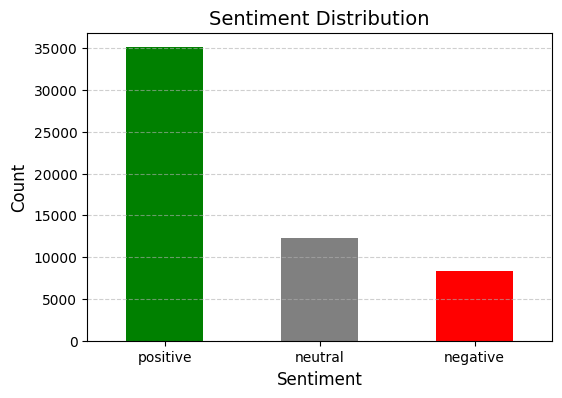

In [ ]:

sentiment_counts = data_translated["sentiment_vader"].value_counts()

plt.figure(figsize=(6,4))
sentiment_counts.plot(kind='bar', color=['green', 'gray', 'red'])
plt.title("Sentiment Distribution", fontsize=14)
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


In [ ]:
print(data_translated['sentiment_updated'].value_counts())    # BEFORE
print(data_translated['sentiment_vader'].value_counts())      # AFTER VADER

sentiment_updated
positive    31512
neutral     17335
negative     6881
Name: count, dtype: int64
sentiment_vader
positive    35089
neutral     12331
negative     8308
Name: count, dtype: int64


In [ ]:
from transformers import pipeline
from tqdm import tqdm


data_translated = pd.read_csv("comments_with_sentiment_updt.csv", encoding="utf-8")

neutral_data = data_translated[data_translated['sentiment_updated'] == 'neutral']


sentiment_model = pipeline(
    "sentiment-analysis",
    model="AmaanP314/youtube-xlm-roberta-base-sentiment-multilingual",
    tokenizer="AmaanP314/youtube-xlm-roberta-base-sentiment-multilingual",
    device=-1,
    truncation=True,
    max_length=512
)


def reclassify_batch(texts, pos_thresh=0.55, neg_thresh=-0.55):
    results = sentiment_model(texts)
    updated_labels = []
    for res in results:
        label = res['label']
        score = res['score']
        if "POS" in label.upper() and score >= pos_thresh:
            updated_labels.append("positive")
        elif "NEG" in label.upper() and score >= pos_thresh:
            updated_labels.append("negative")
        else:
            updated_labels.append("neutral")
    return updated_labels

batch_size = 32
all_updated_labels = []

for i in tqdm(range(0, len(neutral_data), batch_size), desc="Reclassifying neutrals"):
    batch_texts = neutral_data['comments_eng'].iloc[i:i+batch_size].tolist()
    batch_labels = reclassify_batch(batch_texts)
    all_updated_labels.extend(batch_labels)



neutral_data['sentiment_confidence'] = all_updated_labels
data_translated.loc[neutral_data.index, 'sentiment_updated'] = neutral_data['sentiment_confidence']

data_translated.to_csv("comments_sentiment_reclassified_batch.csv", index=False, encoding="utf-8")

print(data_translated['sentiment_updated'].value_counts())


Device set to use cpu
Reclassifying neutrals:   4%|▎         | 21/593 [01:10<30:30,  3.20s/it]

Vectorizer

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle

texts = data_translated['comments_english'].astype(str).tolist()


vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words='english'
)

X = vectorizer.fit_transform(texts)

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Vectorizer yaradıldı və saxlanıldı.")


Vectorizer yaradıldı və saxlanıldı.


In [ ]:
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(sentiment_model, f)

Logistic Regression

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import pickle

data = pd.read_csv("comments_with_sentiment_updt.csv")


X = data["comments_eng"].fillna("")
y = data["sentiment_updated"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


vectorizer = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)


y_pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print(" Model və vectorizer uğurla saxlanıldı!")


Accuracy: 0.697776582391967
              precision    recall  f1-score   support

    negative       0.71      0.38      0.49      1331
     neutral       0.67      0.54      0.60      3792
    positive       0.71      0.87      0.78      6031

    accuracy                           0.70     11154
   macro avg       0.70      0.59      0.62     11154
weighted avg       0.70      0.70      0.68     11154

 Model və vectorizer uğurla saxlanıldı!
